# Phase 3 — Solar resource scoring

**Land-adjusted model:** Primary model uses the **core feature set** (honest OOF R²); extended weather-distribution features from notebook 01 are kept as a diagnostic ablation only. Screening still uses observed percentiles.

Phase 3 screening uses three layers:

1. **Observed** — `shortwave_mean` from Phase 1 weather (**daytime-only** mean when `shortwave > 0`; not diluted by night zeros)
2. **Land-adjusted (OOF)** — XGBoost on location + NLCD + met + solar context (no `shortwave_mean` leakage columns)
3. **Screening score** — percentile rank of observed resource within gateway + NY cells

| Input | Output |
|-------|--------|
| `cells_passing_gateway.parquet` | `solar_scores_by_cell.parquet` |
| | `models/solar_resource.joblib` |
| | `data/processed/solar_resource_cv_report.json` |
| | `maps/solar_resource_ny.html` |

**Requires:** `05` (`in_ny_state`), `06` (gateway pass).

In [1]:
N_CV_FOLDS = 5
RANDOM_STATE = 42
SPATIAL_BLOCK_DEG = 0.5

import json
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import geopandas as gpd
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import plotly.graph_objects as go
import xgboost as xgb
import yaml
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold

ROOT = Path('../..').resolve()
INPUT_PATH = ROOT / 'data' / 'processed' / 'cells_passing_gateway.parquet'
SCORES_PATH = ROOT / 'data' / 'processed' / 'solar_scores_by_cell.parquet'
CV_REPORT_PATH = ROOT / 'data' / 'processed' / 'solar_resource_cv_report.json'
MODEL_PATH = ROOT / 'models' / 'solar_resource.joblib'
CONFIG_PATH = ROOT / 'models' / 'solar_resource_config.yaml'
MAP_PATH = ROOT / 'maps' / 'solar_resource_ny.html'
NY_BOUNDARY_PATH = ROOT / 'data' / 'ref' / 'ny_state_boundary.geojson'

TARGET = 'shortwave_mean'
BASE_FEATURES = [
    'latitude', 'longitude', 'dist_to_transmission_km',
    'temperature_mean', 'surface_pressure_mean',
]
# notebook 01 solar context (exclude target + monthly/seasonal means)
WEATHER_R1_FEATURES = [
    'shortwave_interannual_std', 'shortwave_intraseasonal_std_mean',
    'direct_mean', 'diffuse_mean',
    'shortwave_diurnal_amplitude', 'clear_sky_index', 'direct_diffuse_ratio',
]

if not INPUT_PATH.exists():
    raise FileNotFoundError(f'Run 06_gateway_filter.ipynb first: {INPUT_PATH}')

for p in [SCORES_PATH.parent, MODEL_PATH.parent, MAP_PATH.parent]:
    p.mkdir(parents=True, exist_ok=True)

print('ROOT:', ROOT)

ROOT: /anvil/projects/x-eve260007/Adaptive-Machine-Learning-for-Clean-Energy-Investment-in-New-York


In [2]:
cells = pl.read_parquet(INPUT_PATH)
if 'in_ny_state' not in cells.columns:
    raise ValueError('Re-run 05_build_master_table.ipynb for in_ny_state')

pdf = cells.filter(pl.col('in_ny_state')).to_pandas()
pdf = pdf.drop(columns=['index_right'], errors='ignore')
print('Gateway-passing cells in NY:', len(pdf))

nlcd_features = [c for c in pdf.columns if c.startswith('frac_class_')]
weather_r1 = [c for c in WEATHER_R1_FEATURES if c in pdf.columns]
land_features_v1 = BASE_FEATURES + nlcd_features
land_features = BASE_FEATURES + weather_r1 + nlcd_features
print('R1 weather features used:', weather_r1)

model_df = pdf.dropna(subset=[TARGET] + land_features).copy()
model_df['spatial_block'] = (
    np.floor(model_df['latitude'] / SPATIAL_BLOCK_DEG) * 10_000
    + np.floor(model_df['longitude'] / SPATIAL_BLOCK_DEG)
).astype(int)

if 'county' not in model_df.columns:
    model_df['county'] = 'unknown'

print('Modeling rows:', len(model_df), '| blocks:', model_df['spatial_block'].nunique())

Gateway-passing cells in NY: 1089
R1 weather features used: ['shortwave_interannual_std', 'shortwave_intraseasonal_std_mean', 'direct_mean', 'diffuse_mean', 'shortwave_diurnal_amplitude', 'clear_sky_index', 'direct_diffuse_ratio']
Modeling rows: 1089 | blocks: 63


In [3]:
X_v1 = model_df[land_features_v1].astype(np.float32)
X_r1 = model_df[land_features].astype(np.float32)
y = model_df[TARGET].astype(np.float32)
groups = model_df['spatial_block'].values

n_splits = min(N_CV_FOLDS, model_df['spatial_block'].nunique())
gkf = GroupKFold(n_splits=n_splits)

xgb_params_v1 = dict(
    n_estimators=120, max_depth=4, learning_rate=0.08,
    subsample=0.85, colsample_bytree=0.85, random_state=RANDOM_STATE,
    n_jobs=4, objective='reg:squarederror',
)
xgb_params_r1 = dict(
    n_estimators=200, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
    random_state=RANDOM_STATE, n_jobs=4, objective='reg:squarederror',
)

fold_rows = []
oof_land = np.zeros(len(model_df), dtype=np.float64)

for fold, (tr, te) in enumerate(gkf.split(X_v1, y, groups)):
    m = xgb.XGBRegressor(**xgb_params_v1)
    m.fit(X_v1.iloc[tr], y.iloc[tr])
    pred = m.predict(X_v1.iloc[te])
    oof_land[te] = pred
    fold_rows.append({
        'fold': fold, 'r2': float(r2_score(y.iloc[te], pred)),
        'mae': float(mean_absolute_error(y.iloc[te], pred)),
    })
    print(f"Fold {fold}: R²={fold_rows[-1]['r2']:.3f} MAE={fold_rows[-1]['mae']:.2f}")

cv_land = {
    'r2': float(r2_score(y, oof_land)),
    'mae': float(mean_absolute_error(y, oof_land)),
    'rmse': float(np.sqrt(mean_squared_error(y, oof_land))),
}
print('Land-adjusted OOF (v1 features):', cv_land)

oof_r1 = np.zeros(len(model_df))
for tr, te in gkf.split(X_r1, y, groups):
    m = xgb.XGBRegressor(**xgb_params_r1)
    m.fit(X_r1.iloc[tr], y.iloc[tr])
    oof_r1[te] = m.predict(X_r1.iloc[te])
cv_r1_r2 = float(r2_score(y, oof_r1))
print(f'Ablation R1 extended OOF R²={cv_r1_r2:.3f} | R1 ΔR²={cv_r1_r2 - cv_land["r2"]:.3f}')


Fold 0: R²=0.899 MAE=1.71
Fold 1: R²=0.738 MAE=2.20


Fold 2: R²=0.870 MAE=1.54
Fold 3: R²=0.795 MAE=1.92


Fold 4: R²=0.688 MAE=1.86
Land-adjusted OOF (v1 features): {'r2': 0.8230209663853795, 'mae': 1.846754342071281, 'rmse': 2.7456772939058545}


Ablation R1 extended OOF R²=0.963 | R1 ΔR²=0.140


In [4]:
final_model = xgb.XGBRegressor(**xgb_params_v1)
final_model.fit(X_v1, y)

observed = model_df[TARGET].values
obs_pct = pd.Series(observed).rank(pct=True).values
opportunity = observed - oof_land
opp_pct = pd.Series(opportunity).rank(pct=True).values

scores = model_df[['latitude', 'longitude', 'county', TARGET]].copy()
scores = scores.rename(columns={TARGET: 'resource_observed'})
scores['resource_observed_pct'] = obs_pct
scores['resource_land_adj_oof'] = oof_land
scores['resource_opportunity_oof'] = opportunity
scores['resource_opportunity_pct'] = opp_pct
scores['resource_screening_score'] = obs_pct

pl.from_pandas(scores).write_parquet(SCORES_PATH)
joblib.dump(final_model, MODEL_PATH)

config = {
    'target': TARGET,
    'model_type': 'land_adjusted',
    'features': land_features_v1,
    'n_cells': len(model_df),
    'cv_group': 'spatial_block',
    'cv_land_adjusted_oof': cv_land,
    'cv_folds': fold_rows,
    'feature_set': 'v1_hybrid_primary',
    'ablation_r1_extended_oof_r2': cv_r1_r2,
    'r1_delta_r2': cv_r1_r2 - cv_land['r2'],
    'scoring_columns': {
        'observed': 'resource_observed',
        'screening': 'resource_screening_score',
        'land_adj_oof': 'resource_land_adj_oof',
        'opportunity_oof': 'resource_opportunity_oof',
    },
}
CV_REPORT_PATH.write_text(json.dumps(config, indent=2), encoding='utf-8')
CONFIG_PATH.write_text(yaml.safe_dump(config, sort_keys=False), encoding='utf-8')

print(f'Scores -> {SCORES_PATH}')
print(f'Model -> {MODEL_PATH}')
scores.describe()

Scores -> /anvil/projects/x-eve260007/Adaptive-Machine-Learning-for-Clean-Energy-Investment-in-New-York/data/processed/solar_scores_by_cell.parquet
Model -> /anvil/projects/x-eve260007/Adaptive-Machine-Learning-for-Clean-Energy-Investment-in-New-York/models/solar_resource.joblib


,latitude,longitude,resource_observed,resource_observed_pct,resource_land_adj_oof,resource_opportunity_oof,resource_opportunity_pct,resource_screening_score
count,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000
mean,42.821405,-75.947438,295.474177,0.500459,295.572895,-0.098719,0.500459,0.500459
std,0.793164,1.675755,6.529623,0.288807,5.699830,2.745163,0.288808,0.288807
min,41.220000,-79.710000,253.240899,0.000918,281.500641,-38.047858,0.000918,0.000918
25%,42.300000,-77.280000,292.036465,0.250230,292.579254,-1.384978,0.250689,0.250230
50%,42.660000,-75.750000,295.786035,0.500459,295.509857,-0.093158,0.500459,0.500459
75%,43.200000,-74.580000,299.050447,0.750230,298.570282,1.194472,0.750230,0.750230
max,44.910000,-73.320000,313.839756,1.000000,310.559845,11.327305,1.000000,1.000000


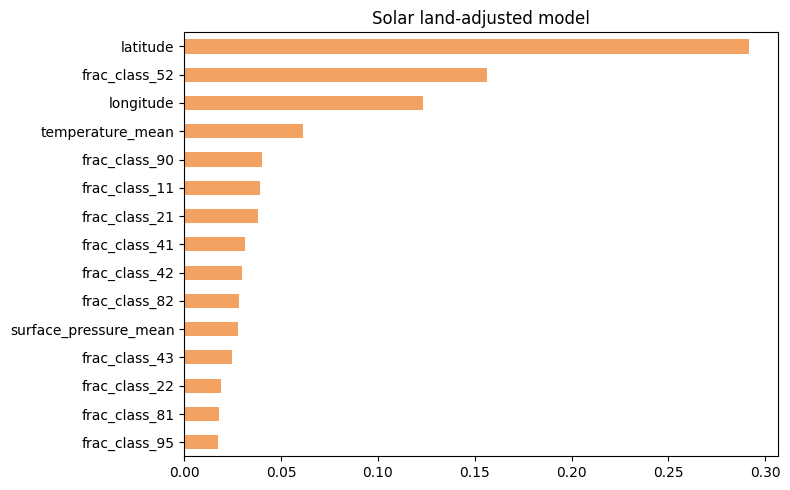

In [5]:
imp = pd.Series(final_model.feature_importances_, index=land_features_v1).sort_values().tail(15)
fig, ax = plt.subplots(figsize=(8, 5))
imp.plot.barh(ax=ax, color='#f4a261')
ax.set_title('Solar land-adjusted model')
fig.tight_layout()
fig.savefig(ROOT / 'data' / 'processed' / 'solar_resource_feature_importance.png', dpi=120)
plt.show()

In [6]:
ny_boundary = gpd.read_file(NY_BOUNDARY_PATH)
outline = ny_boundary.boundary.iloc[0]

fig = go.Figure()
fig.add_trace(go.Scattermap(
    lat=scores['latitude'], lon=scores['longitude'], mode='markers',
    marker=dict(size=9, color=scores['resource_screening_score'],
                colorscale='YlOrRd', showscale=True,
                colorbar=dict(title='Screening score'), opacity=0.65),
    text=[f"obs={r.resource_observed:.1f} oof={r.resource_land_adj_oof:.1f}" for r in scores.itertuples()],
    hoverinfo='text',
))
fig.add_trace(go.Scattermap(
    lat=list(outline.xy[1]), lon=list(outline.xy[0]), mode='lines',
    line=dict(width=2, color='#333'), hoverinfo='skip', showlegend=False,
))
fig.update_layout(
    map=dict(style='carto-positron', center=dict(lat=42.9, lon=-75.8), zoom=5.5),
    title='Solar screening score (observed shortwave percentile, NY gateway cells)',
    height=800, margin=dict(r=0, t=40, l=0, b=0),
)
fig.write_html(str(MAP_PATH), include_plotlyjs='cdn')
print(f'Map -> {MAP_PATH}')

Map -> /anvil/projects/x-eve260007/Adaptive-Machine-Learning-for-Clean-Energy-Investment-in-New-York/maps/solar_resource_ny.html
